# Physics-Informed Neural Networks (PINNs)

One of the most powerful applications of automatic differentiation is in Physics-Informed Neural Networks. PINNs use automatic differentiation to enforce physical laws (differential equations) during training.

Let's solve a simple ordinary differential equation (ODE):
$$\frac{dy}{dx} = -y$$

With initial condition $y(0) = 1$, the analytical solution is $y = e^{-x}$.

Instead of just fitting data, we'll train the neural network to satisfy the differential equation directly!

# Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

In [4]:
plt.style.use('dark_background')

## Mathematical Foundation of Physics-Informed Neural Networks

### The Problem Setup

We want to solve the ordinary differential equation:
$$\frac{dy}{dx} = -y$$

with the initial condition:
$$y(0) = 1$$

The analytical solution to this ODE is:
$$y(x) = e^{-x}$$

### Neural Network Approximation

Instead of solving this analytically, we use a neural network $ NN(x; \theta)$ to approximate the solution $y(x)$, where $\theta$ represents the network parameters (weights and biases).

Our goal is to find parameters $\theta^*$ such that:
$$ NN(x; \theta^*) \approx y(x) = e^{-x}$$

### Physics Loss: Enforcing the Differential Equation

The key insight of PINNs is to enforce the differential equation as a constraint during training. We define the **physics residual** as:

$$\mathcal{R}(x; \theta) = \frac{d NN}{dx} +  NN(x; \theta)$$

For the exact solution, this residual should be zero everywhere:
$$\frac{dy}{dx} + y = -y + y = 0$$

The **physics loss** is then defined as the mean squared residual over the training domain $\Omega$:

$$\mathcal{L}_{\text{physics}} = \frac{1}{N} \sum_{i=1}^{N} \left|\mathcal{R}(x_i; \theta)\right|^2 = \frac{1}{N} \sum_{i=1}^{N} \left|\frac{d NN}{dx}\bigg|_{x_i} +  NN(x_i; \theta)\right|^2$$

where $\{x_i\}_{i=1}^N$ are collocation points sampled from the domain.

### Initial Condition Loss

To enforce the initial condition $y(0) = 1$, we define:

$$\mathcal{L}_{\text{IC}} = | NN(0; \theta) - 1|^2$$

### Automatic Differentiation for Computing Derivatives

The crucial component is computing $\frac{d NN}{dx}$ efficiently. This is where automatic differentiation shines:

1. **Forward pass**: Compute $ NN(x; \theta)$ with `x.requires_grad_(True)`
2. **Backward pass**: Use `torch.autograd.grad()` to compute $\frac{d NN}{dx}$

The automatic differentiation computes the exact derivative (up to machine precision), not a finite difference approximation.

### Total Loss Function

The total loss combines both physics and initial condition constraints:

$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{physics}} + \lambda_{\text{IC}} \mathcal{L}_{\text{IC}}$$

where $\lambda_{\text{IC}}$ is a weighting parameter to balance the importance of the initial condition.

### Why This Works: The Variational Principle

From a mathematical perspective, PINNs solve the differential equation by minimizing the residual in a least-squares sense. This is related to the **method of weighted residuals** in numerical analysis.

The neural network learns to satisfy:
1. **Differential equation**: $\frac{dy}{dx} + y = 0$ at all collocation points
2. **Boundary/Initial conditions**: $y(0) = 1$

### Key Advantages of PINNs

1. **No training data required**: Unlike traditional ML, we don't need solution data
2. **Automatic differentiation**: Exact derivatives without finite difference errors
3. **Flexible domains**: Can handle complex geometries and boundary conditions
4. **Physics consistency**: Solutions automatically satisfy the governing equations

### Mathematical Implementation Details

In the code:
```python
def physics_loss(model, x):
    x.requires_grad_(True)  # Enable gradient computation
    y = model(x)           # Forward pass: y = N(x; θ)
    
    # Compute dy/dx using automatic differentiation
    dy_dx = torch.autograd.grad(outputs=y, inputs=x, ...)[0]
    
    # Physics residual: dy/dx + y
    physics_residual = dy_dx + y
    
    # Mean squared residual
    return torch.mean(physics_residual**2)
```

The `torch.autograd.grad()` function computes:
$$\frac{d NN}{dx} = \frac{\partial}{\partial x}\left[\text{neural network output}\right]$$

This derivative is computed exactly using the chain rule through all layers of the network.

# PINN

In [5]:
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
    
    def forward(self, x):
        return self.net(x)

def physics_loss(model, x):
    """
    Compute the physics-informed loss for the ODE: dy/dx = -y
    """
    x.requires_grad_(True)
    y = model(x)
    
    # Compute dy/dx using automatic differentiation
    dy_dx = torch.autograd.grad(
        outputs=y,
        inputs=x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True
    )[0]
    
    # Physics loss: |dy/dx + y|^2
    physics_residual = dy_dx + y
    return torch.mean(physics_residual**2)

def initial_condition_loss(model, x0, y0):
    """
    Enforce initial condition y(0) = 1
    """
    y_pred = model(x0)
    return torch.mean((y_pred - y0)**2)

# Training setup
pinn_model = PINN()
pinn_optimizer = optim.Adam(pinn_model.parameters(), lr=0.01)

# Training domain
x_train = torch.linspace(0, 3, 100).unsqueeze(1)
x0 = torch.tensor([[0.0]])  # Initial condition point
y0 = torch.tensor([[1.0]])  # Initial condition value

# Training loop
epochs = 5000
physics_losses = []
ic_losses = []

for epoch in range(epochs):
    pinn_optimizer.zero_grad()
    
    # Compute losses
    phys_loss = physics_loss(pinn_model, x_train)
    ic_loss = initial_condition_loss(pinn_model, x0, y0)
    
    # Total loss (weighted combination)
    total_loss = phys_loss + 10 * ic_loss  # Weight IC more heavily
    
    total_loss.backward()
    pinn_optimizer.step()
    
    if epoch % 500 == 0:
        print(f'Epoch {epoch}, Physics Loss: {phys_loss.item():.6f}, IC Loss: {ic_loss.item():.6f}')
    
    physics_losses.append(phys_loss.item())
    ic_losses.append(ic_loss.item())

Epoch 0, Physics Loss: 0.011853, IC Loss: 0.730411
Epoch 500, Physics Loss: 0.000017, IC Loss: 0.000000
Epoch 1000, Physics Loss: 0.000002, IC Loss: 0.000000
Epoch 1500, Physics Loss: 0.000001, IC Loss: 0.000000
Epoch 2000, Physics Loss: 0.000000, IC Loss: 0.000000
Epoch 2500, Physics Loss: 0.000001, IC Loss: 0.000000
Epoch 3000, Physics Loss: 0.000004, IC Loss: 0.000000
Epoch 3500, Physics Loss: 0.000034, IC Loss: 0.000097
Epoch 4000, Physics Loss: 0.000009, IC Loss: 0.000003
Epoch 4500, Physics Loss: 0.000002, IC Loss: 0.000000


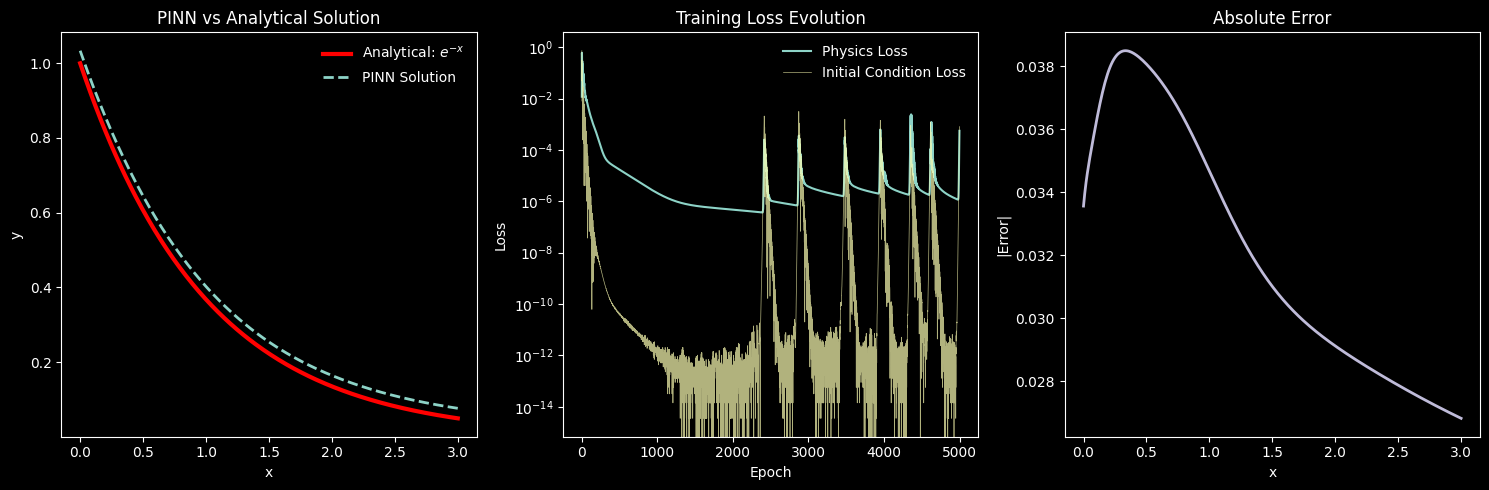

Maximum absolute error: 0.038495
Mean absolute error: 0.032074


In [11]:
# Evaluate the trained PINN
x_test = torch.linspace(0, 3, 300).unsqueeze(1)
with torch.no_grad():
    y_pinn = pinn_model(x_test)

# Analytical solution
y_analytical = torch.exp(-x_test)

# Plot results
plt.figure(figsize=(15, 5))

# Solution comparison
plt.subplot(1, 3, 1)
plt.plot(x_test.numpy(), y_analytical.numpy(), 'r-', label='Analytical: $e^{-x}$', linewidth=3)
plt.plot(x_test.numpy(), y_pinn.numpy(), '--', label='PINN Solution', linewidth=2, color="C0")
plt.xlabel('x')
plt.ylabel('y')
plt.title('PINN vs Analytical Solution')
plt.legend(frameon=False)

# Training loss curves
plt.subplot(1, 3, 2)
plt.plot(physics_losses, label='Physics Loss')
plt.plot(ic_losses, label='Initial Condition Loss', alpha=0.7, lw=0.5)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Evolution')
plt.legend(frameon=False)
plt.yscale('log')

# Error analysis
error = torch.abs(y_pinn - y_analytical)
plt.subplot(1, 3, 3)
plt.plot(x_test.numpy(), error.numpy(), '-', linewidth=2, color="C2")
plt.xlabel('x')
plt.ylabel('|Error|')
plt.title('Absolute Error')

plt.tight_layout()
plt.show()

print(f"Maximum absolute error: {torch.max(error).item():.6f}")
print(f"Mean absolute error: {torch.mean(error).item():.6f}")

# Future Extensions

This notebook could be extended with the following advanced topics:

## 1. Multi-dimensional Automatic Differentiation
- Functions of multiple variables: $f(x, y) = x^2 + y^2$
- Jacobian matrices and vector-valued functions
- Gradient computation for optimization

## 2. Computational Efficiency Analysis
- Comparing automatic differentiation vs numerical differentiation
- Memory usage and computational complexity
- Forward-mode vs reverse-mode automatic differentiation

## 3. Advanced PINNs
- Partial differential equations (PDEs)
- Heat equation: $\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}$
- Wave equation and boundary conditions

## 4. Optimization Landscapes
- Visualizing loss surfaces
- Gradient descent path visualization
- Local minima and saddle points

## 5. Practical Applications
- Neural ODE solvers
- Scientific machine learning
- Inverse problems in physics